# Module 3: Data Center Project - Python

<a target="_blank" href="https://colab.research.google.com/github/yalinli2/EnvEtools/blob/main/course_modules/3_Data_Center_Python.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

<a target="_blank" href="https:///mybinder.org/v2/gh/yalinli2/EnvEtools/main?urlpath=%2Fdoc%2Ftree%2Fcourse_modules%2F3_Data_Center_Python.ipynb">
  <img src="https://mybinder.org/badge_logo.svg" alt="Open In Binder"/>
</a>

## Example workflow.
* Import data center information from [FracTracker](https://www.fractracker.org/2025/07/national-data-centers-tracker/) (Excel/programming languages).
    - Backup address from [Business Insider](https://www.businessinsider.com/data-center-locations-us-map-ai-boom-2025-9)
    - Backup address from [Data Center Map](www.datacentermap.com)
* Clean-up/extract addresses (Excel/programming languages).
* Download and extract drought data from [Drought Monitor](https://droughtmonitor.unl.edu) (Excel/programming languages).
* Download and extract electricity generation and emission data from [eGRID](https://www.epa.gov/egrid/detailed-data) (Excel/programming languages).
* Superimpose data center location and water/energy data (GIS, tableau).

## Collect Data Center Information

In [1]:
### Import Data
import pandas as pd
path = 'data/3_Data_Centers_Database.xlsx'
datacenter = pd.read_excel(path, sheet_name='FracTracker Data Centers')

In [2]:
# Take a look at the data
datacenter.head() # `head` shows the first five rows, `tail` shows the last five rows

,facility_name,address,city,state,zip,county,lat,long,status,location_confidence,...,other_info,information_source,info_source_1,info_source_2,info_source_3,info_source_4,info_source_5,info_source_6,info_source_7,info_source_8
0,"""Project Marvel""",Rock Mountain Lake Rd,Bessemer,AL,35022.0,Jefferson,33.342000,-87.034100,Proposed,High,...,100 acres to be cleared,Media Monitoring,https://www.datacenterdynamics.com/en/news/700...,https://www.youtube.com/watch?v=ICSrvQ7meow&ab...,https://www.al.com/news/2025/06/14-billion-pro...,https://www.wbrc.com/2025/09/14/bessemer-resid...,https://www.datacenterdynamics.com/en/news/ala...,NaN,NaN,NaN
1,DC Blox,433 6th St S,Birmingham,AL,35233.0,Jefferson,33.500510,-86.821000,Operating,High,...,NaN,Media Monitoring,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Google data center,48809 Alabama 277,Bridgeport,AL,35740.0,Jackson,34.920190,-85.744600,Operating,High,...,NaN,Media Monitoring,https://www.madeinalabama.com/2018/04/google-k...,https://claycorp.com/work/mission-critical,NaN,NaN,NaN,NaN,NaN,NaN
3,Western Hospitality Partners data center,Childersburg Industrial Park,Childersburg,AL,35044.0,Talladega,33.340885,-86.336205,Proposed,Medium,...,NaN,Media Monitoring,https://www.datacenterdynamics.com/en/news/pla...,https://www.childersburg.org/childersburg-indu...,NaN,NaN,NaN,NaN,NaN,NaN
4,DC Blox,333 Diamond Dr NW,Huntsville,AL,35806.0,Madison,34.710030,-86.693000,Operating,High,...,NaN,Media Monitoring,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


We can clearly see that location information is in address, city, state, zip, county, latitude, and longitude

In [3]:
# Assume we are only interested in New Jersey's data centers
datacenter[datacenter.state=='NJ']

,facility_name,address,city,state,zip,county,lat,long,status,location_confidence,...,other_info,information_source,info_source_1,info_source_2,info_source_3,info_source_4,info_source_5,info_source_6,info_source_7,info_source_8
447,Comcast data center,92 W Main St,Clinton,NJ,8809.0,Hunterdon,40.632840,-74.919100,Proposed,High,...,NaN,Media Monitoring,https://www.datacenterdynamics.com/en/news/com...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
448,Data center: Joint Base McGuire-Dix-Lakehurst ...,3021 McGuire Blvd,Fort Dix,NJ,8641.0,Burlington,40.016610,-74.608765,Proposed,Medium,...,NaN,Media Monitoring,https://www.datacenterdynamics.com/en/news/us-...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
449,DataVerge,111 Town Square Place,Jersey City,NJ,7310.0,Hudson,40.726536,-74.033480,Operating,High,...,NaN,Media Monitoring,https://dataverge.com/interconnected-colocatio...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
450,Comcast data center,650 Centerton Rd,Moorestown,NJ,8057.0,Burlington,39.989390,-74.889600,Proposed,High,...,NaN,Media Monitoring,https://www.datacenterdynamics.com/en/news/com...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
451,GI Partners data center,492 River Rd,Nutley,NJ,7110.0,Essex,40.821510,-74.134200,Operating,High,...,NaN,Media Monitoring,https://www.datacenterdynamics.com/en/news/gi-...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
452,Prism Capital Partners data center,Cathedral Ave & Kingsland St,Nutley,NJ,7110.0,Essex,40.829400,-74.153600,Proposed,High,...,NaN,Media Monitoring,https://www.datacenterdynamics.com/en/news/app...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
453,Nebius data center,Lincoln and Sheridan Aves,Vineland,NJ,8361.0,Cumberland,39.430120,-75.013100,Proposed,High,...,NaN,Media Monitoring,https://www.msn.com/en-us/money/companies/mass...,https://www.nj.com/news/2025/07/massive-ai-dat...,https://www.silive.com/nation/2025/07/gigantic...,NaN,NaN,NaN,NaN,NaN
454,NJFX,1410 Wall Church Rd,Wall,NJ,7719.0,Monmouth,40.161446,-74.053340,Operating,High,...,NaN,Media Monitoring,https://www.datacenterdynamics.com/en/news/njf...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1355,Proposed data center,~100 Jersey Ave,New Brunswick,NJ,8901.0,Middlesex,40.486620,-74.458430,Cancelled,High,...,NaN,Media Monitoring,https://www.datacenterdynamics.com/en/news/pro...,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Our goal is to extract the location information for each entry, so that we will be able to plot the data centers on a map
# Take a look at all columns
for i in datacenter.columns: print(i)

facility_name
address
city
state
zip
county
lat
long
status
location_confidence
purpose
operator_name
tenant
mw
sizerank
power_source
dedicated_power_plant
number_of_generators
number_of_buildings
cooling_source
cooling_type
facility_size_sqft
property_size_acres
project_cost
expected_date_online
community_pushback
advocacy_information
resistance_status
nda
community_group_website_1
community_group_website_2
petition_url
other_info
information_source
info_source_1
info_source_2
info_source_3
info_source_4
info_source_5
info_source_6
info_source_7
info_source_8


In [5]:
# Make a new dataframe with just those data
nj = datacenter[datacenter.state=='NJ'].copy()
nj

,facility_name,address,city,state,zip,county,lat,long,status,location_confidence,...,other_info,information_source,info_source_1,info_source_2,info_source_3,info_source_4,info_source_5,info_source_6,info_source_7,info_source_8
447,Comcast data center,92 W Main St,Clinton,NJ,8809.0,Hunterdon,40.632840,-74.919100,Proposed,High,...,NaN,Media Monitoring,https://www.datacenterdynamics.com/en/news/com...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
448,Data center: Joint Base McGuire-Dix-Lakehurst ...,3021 McGuire Blvd,Fort Dix,NJ,8641.0,Burlington,40.016610,-74.608765,Proposed,Medium,...,NaN,Media Monitoring,https://www.datacenterdynamics.com/en/news/us-...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
449,DataVerge,111 Town Square Place,Jersey City,NJ,7310.0,Hudson,40.726536,-74.033480,Operating,High,...,NaN,Media Monitoring,https://dataverge.com/interconnected-colocatio...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
450,Comcast data center,650 Centerton Rd,Moorestown,NJ,8057.0,Burlington,39.989390,-74.889600,Proposed,High,...,NaN,Media Monitoring,https://www.datacenterdynamics.com/en/news/com...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
451,GI Partners data center,492 River Rd,Nutley,NJ,7110.0,Essex,40.821510,-74.134200,Operating,High,...,NaN,Media Monitoring,https://www.datacenterdynamics.com/en/news/gi-...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
452,Prism Capital Partners data center,Cathedral Ave & Kingsland St,Nutley,NJ,7110.0,Essex,40.829400,-74.153600,Proposed,High,...,NaN,Media Monitoring,https://www.datacenterdynamics.com/en/news/app...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
453,Nebius data center,Lincoln and Sheridan Aves,Vineland,NJ,8361.0,Cumberland,39.430120,-75.013100,Proposed,High,...,NaN,Media Monitoring,https://www.msn.com/en-us/money/companies/mass...,https://www.nj.com/news/2025/07/massive-ai-dat...,https://www.silive.com/nation/2025/07/gigantic...,NaN,NaN,NaN,NaN,NaN
454,NJFX,1410 Wall Church Rd,Wall,NJ,7719.0,Monmouth,40.161446,-74.053340,Operating,High,...,NaN,Media Monitoring,https://www.datacenterdynamics.com/en/news/njf...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1355,Proposed data center,~100 Jersey Ave,New Brunswick,NJ,8901.0,Middlesex,40.486620,-74.458430,Cancelled,High,...,NaN,Media Monitoring,https://www.datacenterdynamics.com/en/news/pro...,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Only select the columns we want
nj_processed = nj.iloc[:, :9]
nj_processed

,facility_name,address,city,state,zip,county,lat,long,status
447,Comcast data center,92 W Main St,Clinton,NJ,8809.0,Hunterdon,40.632840,-74.919100,Proposed
448,Data center: Joint Base McGuire-Dix-Lakehurst ...,3021 McGuire Blvd,Fort Dix,NJ,8641.0,Burlington,40.016610,-74.608765,Proposed
449,DataVerge,111 Town Square Place,Jersey City,NJ,7310.0,Hudson,40.726536,-74.033480,Operating
450,Comcast data center,650 Centerton Rd,Moorestown,NJ,8057.0,Burlington,39.989390,-74.889600,Proposed
451,GI Partners data center,492 River Rd,Nutley,NJ,7110.0,Essex,40.821510,-74.134200,Operating
452,Prism Capital Partners data center,Cathedral Ave & Kingsland St,Nutley,NJ,7110.0,Essex,40.829400,-74.153600,Proposed
453,Nebius data center,Lincoln and Sheridan Aves,Vineland,NJ,8361.0,Cumberland,39.430120,-75.013100,Proposed
454,NJFX,1410 Wall Church Rd,Wall,NJ,7719.0,Monmouth,40.161446,-74.053340,Operating
1355,Proposed data center,~100 Jersey Ave,New Brunswick,NJ,8901.0,Middlesex,40.486620,-74.458430,Cancelled


In [7]:
# Reset the index, `inplace` just means we want the changes to be applied to the original dataframe
# `drop` means we don't insert a new index column
nj_processed.reset_index(inplace=True, drop=True)
nj_processed

,facility_name,address,city,state,zip,county,lat,long,status
0,Comcast data center,92 W Main St,Clinton,NJ,8809.0,Hunterdon,40.632840,-74.919100,Proposed
1,Data center: Joint Base McGuire-Dix-Lakehurst ...,3021 McGuire Blvd,Fort Dix,NJ,8641.0,Burlington,40.016610,-74.608765,Proposed
2,DataVerge,111 Town Square Place,Jersey City,NJ,7310.0,Hudson,40.726536,-74.033480,Operating
3,Comcast data center,650 Centerton Rd,Moorestown,NJ,8057.0,Burlington,39.989390,-74.889600,Proposed
4,GI Partners data center,492 River Rd,Nutley,NJ,7110.0,Essex,40.821510,-74.134200,Operating
5,Prism Capital Partners data center,Cathedral Ave & Kingsland St,Nutley,NJ,7110.0,Essex,40.829400,-74.153600,Proposed
6,Nebius data center,Lincoln and Sheridan Aves,Vineland,NJ,8361.0,Cumberland,39.430120,-75.013100,Proposed
7,NJFX,1410 Wall Church Rd,Wall,NJ,7719.0,Monmouth,40.161446,-74.053340,Operating
8,Proposed data center,~100 Jersey Ave,New Brunswick,NJ,8901.0,Middlesex,40.486620,-74.458430,Cancelled


In [8]:
# We can see that zip looks weird, that is because Python is treating them as numbers,
# which automatically eliminates the "0" in NJ zipcodes
nj_processed.zip.dtype

dtype('float64')

In [9]:
# Let's first convert the data type to string
nj_processed.zip = nj_processed.zip.astype(str)
nj_processed.zip.dtype

<StringDtype(storage='python', na_value=nan)>

In [10]:
# Then we can fix the zipcode by appending a "0" at the beginning of all zipcodes, and removing the ".0" at the end
# First we try the first entry as an example
first_entry = nj_processed.zip[0]
first_entry

'8809.0'

In [11]:
# We can split the string at the '.' position
first_entry_splitted = first_entry.split('.')
first_entry_splitted

['8809', '0']

In [12]:
# Then add a '0' in front of the 0th element
first_entry_processed = '0' + first_entry_splitted[0]
first_entry_processed

'08809'

In [13]:
# We can define a function to do this
def convert_zip(old_zip):
    old_zip_splitted = old_zip.split('.')
    new_zip = '0' + old_zip_splitted[0]
    return new_zip

In [14]:
# Try it out
convert_zip(first_entry)

'08809'

In [15]:
# We can then apply this entire function to the zip column
nj_processed.zip.apply(convert_zip)

0    08809
1    08641
2    07310
3    08057
4    07110
5    07110
6    08361
7    07719
8    08901
Name: zip, dtype: str

In [16]:
# Note that pandas doesn't automatically replace the previous column
nj_processed

,facility_name,address,city,state,zip,county,lat,long,status
0,Comcast data center,92 W Main St,Clinton,NJ,8809.0,Hunterdon,40.632840,-74.919100,Proposed
1,Data center: Joint Base McGuire-Dix-Lakehurst ...,3021 McGuire Blvd,Fort Dix,NJ,8641.0,Burlington,40.016610,-74.608765,Proposed
2,DataVerge,111 Town Square Place,Jersey City,NJ,7310.0,Hudson,40.726536,-74.033480,Operating
3,Comcast data center,650 Centerton Rd,Moorestown,NJ,8057.0,Burlington,39.989390,-74.889600,Proposed
4,GI Partners data center,492 River Rd,Nutley,NJ,7110.0,Essex,40.821510,-74.134200,Operating
5,Prism Capital Partners data center,Cathedral Ave & Kingsland St,Nutley,NJ,7110.0,Essex,40.829400,-74.153600,Proposed
6,Nebius data center,Lincoln and Sheridan Aves,Vineland,NJ,8361.0,Cumberland,39.430120,-75.013100,Proposed
7,NJFX,1410 Wall Church Rd,Wall,NJ,7719.0,Monmouth,40.161446,-74.053340,Operating
8,Proposed data center,~100 Jersey Ave,New Brunswick,NJ,8901.0,Middlesex,40.486620,-74.458430,Cancelled


In [17]:
# Explicitly ask pandas to replace the column
nj_processed.zip = nj_processed.zip.apply(convert_zip)
nj_processed

,facility_name,address,city,state,zip,county,lat,long,status
0,Comcast data center,92 W Main St,Clinton,NJ,08809,Hunterdon,40.632840,-74.919100,Proposed
1,Data center: Joint Base McGuire-Dix-Lakehurst ...,3021 McGuire Blvd,Fort Dix,NJ,08641,Burlington,40.016610,-74.608765,Proposed
2,DataVerge,111 Town Square Place,Jersey City,NJ,07310,Hudson,40.726536,-74.033480,Operating
3,Comcast data center,650 Centerton Rd,Moorestown,NJ,08057,Burlington,39.989390,-74.889600,Proposed
4,GI Partners data center,492 River Rd,Nutley,NJ,07110,Essex,40.821510,-74.134200,Operating
5,Prism Capital Partners data center,Cathedral Ave & Kingsland St,Nutley,NJ,07110,Essex,40.829400,-74.153600,Proposed
6,Nebius data center,Lincoln and Sheridan Aves,Vineland,NJ,08361,Cumberland,39.430120,-75.013100,Proposed
7,NJFX,1410 Wall Church Rd,Wall,NJ,07719,Monmouth,40.161446,-74.053340,Operating
8,Proposed data center,~100 Jersey Ave,New Brunswick,NJ,08901,Middlesex,40.486620,-74.458430,Cancelled


In [18]:
# Finally, we output the processed data
nj_processed.to_csv('data/3_Data_Centers_NJ.csv')

## Collect Drought Data

We will use drought data to represent water availability. You can easily download the drought data from [Drought Monitor](https://droughtmonitor.unl.edu).

You can use whatever data you think reasonable to indicate drought severity, for this illustrative example, because it's in NJ, I will use drought data in NJ counties for the past 5 years, which can be found under Data/Data Download/Comprehensive Statistics

<img src='../images/3_drought_monitor.png' alt='Drought Monitor' width=600/>

In [19]:
# Import data to see what it looks like
drought = pd.read_csv('data/3_DroughtMonitorNJ.csv')
drought.head()

,MapDate,FIPS,County,State,None,D0,D1,D2,D3,D4,ValidStart,ValidEnd,StatisticFormatID
0,20251118,34001,Atlantic County,NJ,83.92,16.08,0.0,0.0,0.0,0.0,2025-11-18,2025-11-24,2
1,20251111,34001,Atlantic County,NJ,83.92,16.08,0.0,0.0,0.0,0.0,2025-11-11,2025-11-17,2
2,20251104,34001,Atlantic County,NJ,83.87,16.13,0.0,0.0,0.0,0.0,2025-11-04,2025-11-10,2
3,20251028,34001,Atlantic County,NJ,84.84,15.16,0.0,0.0,0.0,0.0,2025-10-28,2025-11-03,2
4,20251021,34001,Atlantic County,NJ,87.91,12.09,0.0,0.0,0.0,0.0,2025-10-21,2025-10-27,2


Since there are 5 different levels (D0 doesn't mean there's no drought), let's use weighted sum as a single indicator, [Drought Severity and Coverage Index](https://droughtmonitor.unl.edu/About/AbouttheData/DSCI.aspx), to represent the total severity.

$$DSCI = D0*1+D1*2+D2*3+D3*4+D4*5$$

In [20]:
drought['DSCI'] = drought.D0*1+drought.D1*2+drought.D2*3+drought.D3*4+drought.D4*5
drought.head()

,MapDate,FIPS,County,State,None,D0,D1,D2,D3,D4,ValidStart,ValidEnd,StatisticFormatID,DSCI
0,20251118,34001,Atlantic County,NJ,83.92,16.08,0.0,0.0,0.0,0.0,2025-11-18,2025-11-24,2,16.08
1,20251111,34001,Atlantic County,NJ,83.92,16.08,0.0,0.0,0.0,0.0,2025-11-11,2025-11-17,2,16.08
2,20251104,34001,Atlantic County,NJ,83.87,16.13,0.0,0.0,0.0,0.0,2025-11-04,2025-11-10,2,16.13
3,20251028,34001,Atlantic County,NJ,84.84,15.16,0.0,0.0,0.0,0.0,2025-10-28,2025-11-03,2,15.16
4,20251021,34001,Atlantic County,NJ,87.91,12.09,0.0,0.0,0.0,0.0,2025-10-21,2025-10-27,2,12.09


In [21]:
# Since we have weekly data over 5 years, we'd like to calculate the average for each county
# First we need to get the names of all counties
counties = drought.County.unique()
counties

<StringArray>
[  'Atlantic County',     'Bergen County', 'Burlington County',
     'Camden County',   'Cape May County', 'Cumberland County',
      'Essex County', 'Gloucester County',     'Hudson County',
  'Hunterdon County',     'Mercer County',  'Middlesex County',
   'Monmouth County',     'Morris County',      'Ocean County',
    'Passaic County',      'Salem County',   'Somerset County',
     'Sussex County',      'Union County',     'Warren County']
Length: 21, dtype: str

In [22]:
# Remove the excess "County" in the name
def remove_county(name):
    return name.replace(" County", "")
drought['County'] = drought.County.apply(remove_county)
counties = drought.County.unique()
counties

<StringArray>
[  'Atlantic',     'Bergen', 'Burlington',     'Camden',   'Cape May',
 'Cumberland',      'Essex', 'Gloucester',     'Hudson',  'Hunterdon',
     'Mercer',  'Middlesex',   'Monmouth',     'Morris',      'Ocean',
    'Passaic',      'Salem',   'Somerset',     'Sussex',      'Union',
     'Warren']
Length: 21, dtype: str

In [23]:
# Then make a new df of all averages
FIPS = [] # Federal Information Processing Standards, we need this to identify the location
dsci_avg = []
for county in counties:
    county_data = drought[drought.County==county]
    FIPS.append(county_data.FIPS.unique()[0]) # FIPS should be the same for each county
    dsci_avg.append(county_data.DSCI.mean())

drought_avg = pd.DataFrame({
    'FIPS': FIPS,
    'County': counties,
    'State': 'New Jersey',
    'Country': 'USA',
    'DSCI': dsci_avg
})
drought_avg.head()

,FIPS,County,State,Country,DSCI
0,34001,Atlantic,New Jersey,USA,75.519464
1,34003,Bergen,New Jersey,USA,55.934138
2,34005,Burlington,New Jersey,USA,55.092605
3,34007,Camden,New Jersey,USA,58.714483
4,34009,Cape May,New Jersey,USA,87.965785


In [24]:
# Save the data for later use
drought_avg.to_csv('data/3_DroughtMonitorNJ_processed.csv')

## Collect Electricity Data

We will use electricity data from [eGRID](https://www.epa.gov/egrid), Emissions & Generation Resource Integrated Database, by the U.S. Environmental Protection Agency (USEPA).

For the illustrative example, I downloaded [eGRID2023](https://www.epa.gov/egrid/detailed-data) here.

<img src='../images/3_egrid.png' alt='eGRID' width=600/>

The eGRID model file is relatively complex, so it's easier to navigate in Excel.

The following information is of interest to us, all of which is in the PLNT23 sheet:
* DOE/EIA ORIS plant or facility code - for identification acorss the different sheets, in case needed
* Plant FIPS state code, Plant FIPS county code, Plant county name, Plant latitude, Plant longitude - location
* Plant annual net generation (MWh) - generated electricity
* Plant annual CO2 equivalent emissions (tons) - GHG emissions

So let's pull out these data.

In [25]:
# Read the file, it's quite large so takes some time
egrid = pd.read_excel('data/3_egrid2023_data_rev2.xlsx', sheet_name='PLNT23')
egrid.head()

,Plant file sequence number,Data Year,Plant state abbreviation,Plant name,DOE/EIA ORIS plant or facility code,Plant transmission or distribution system owner name,Plant transmission or distribution system owner ID,Utility name,Utility ID,Plant-level sector,...,Plant geothermal generation percent (resource mix),Plant other fossil generation percent (resource mix),Plant other unknown / purchased fuel generation percent (resource mix),Plant total nonrenewables generation percent (resource mix),Plant total renewables generation percent (resource mix),Plant total nonrenewables other unknown/purchased generation percent (resource mix),Plant total nonhydro renewables generation percent (resource mix),Plant total combustion generation percent (resource mix),Plant total noncombustion generation percent (resource mix),Plant total noncombustion other unknown/purchased generation percent (resource mix)
0,SEQPLT23,YEAR,PSTATABB,PNAME,ORISPL,OPRNAME,OPRCODE,UTLSRVNM,UTLSRVID,SECTOR,...,PLGTPR,PLOFPR,PLOPPR,PLTNPR,PLTRPR,PLTOPR,PLTHPR,PLCYPR,PLCNPR,PLCOPR
1,1,2023,AK,Alakanuk,57053,"Alaska Village Elec Coop, Inc",221,"Alaska Village Elec Coop, Inc",221,Electric Utility,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,2023,AK,Allison Creek Hydro,58982,"Copper Valley Elec Assn, Inc",4329,"Copper Valley Elec Assn, Inc",4329,Electric Utility,...,0,0,0,0,1,0,0,0,1,0
3,3,2023,AK,Ambler,60243,"Alaska Village Elec Coop, Inc",221,"Alaska Village Elec Coop, Inc",221,Electric Utility,...,0,0,0,1,0,0,0,1,0,0
4,4,2023,AK,Angoon,7462,"Inside Passage Elec Coop, Inc",18963,"Inside Passage Elec Coop, Inc",18963,Electric Utility,...,0,0,0,1,0,0,0,1,0,0


In [26]:
# We just need data for NJ
nj = egrid[egrid['Plant state abbreviation']=='NJ'].copy()
nj.head()

,Plant file sequence number,Data Year,Plant state abbreviation,Plant name,DOE/EIA ORIS plant or facility code,Plant transmission or distribution system owner name,Plant transmission or distribution system owner ID,Utility name,Utility ID,Plant-level sector,...,Plant geothermal generation percent (resource mix),Plant other fossil generation percent (resource mix),Plant other unknown / purchased fuel generation percent (resource mix),Plant total nonrenewables generation percent (resource mix),Plant total renewables generation percent (resource mix),Plant total nonrenewables other unknown/purchased generation percent (resource mix),Plant total nonhydro renewables generation percent (resource mix),Plant total combustion generation percent (resource mix),Plant total noncombustion generation percent (resource mix),Plant total noncombustion other unknown/purchased generation percent (resource mix)
7970,7970,2023,NJ,"10 Finderne Avenue Solar, LLC",64023,Public Service Elec & Gas Co,15477,Greenbacker Renewable Energy Corporation,60025,IPP Non-CHP,...,0,0,0,0,1,0,1,0,1,0
7971,7971,2023,NJ,"101 Carnegie Center Solar, LLC",64025,Public Service Elec & Gas Co,15477,Greenbacker Renewable Energy Corporation,60025,IPP Non-CHP,...,0,0,0,0,1,0,1,0,1,0
7972,7972,2023,NJ,12 Applegate Solar LLC,59371,Jersey Central Power & Lt Co,9726,G&S Operations LLC,62629,IPP Non-CHP,...,0,0,0,0,1,0,1,0,1,0
7973,7973,2023,NJ,145 Talmadge Solar,57458,Public Service Elec & Gas Co,15477,Avidan Energy Solutions,56777,IPP Non-CHP,...,0,0,0,0,1,0,1,0,1,0
7974,7974,2023,NJ,180 Raritan Solar,58187,Public Service Elec & Gas Co,15477,"180 Raritan Energy Solutions, LLC",58164,IPP Non-CHP,...,0,0,0,0,1,0,1,0,1,0


In [27]:
# To see all column names
for i in nj.columns: print (i)

Plant file sequence number
Data Year
Plant state abbreviation
Plant name
DOE/EIA ORIS plant or facility code
Plant transmission or distribution system owner name
Plant transmission or distribution system owner ID
Utility name
Utility ID
Plant-level sector
Balancing Authority Name
Balancing Authority Code
NERC region acronym
eGRID subregion acronym
eGRID subregion name
Plant associated ISO/RTO Territory
Plant FIPS state code
Plant FIPS county code
Plant county name
Plant latitude
Plant longitude
CAPD Program Flag
Number of units
Number of generators
Plant primary fuel
Plant primary fuel category
Flag indicating if the plant burned or generated any amount of coal
Plant capacity factor
Plant nameplate capacity (MW)
Nonbaseload Factor
Biogas/ biomass plant adjustment flag
Combined heat and power (CHP) plant adjustment flag
CHP plant useful thermal output (MMBtu)
CHP plant power to heat ratio
CHP plant electric allocation factor
Plant pumped storage flag
Plant annual heat input from combust

In [28]:
# Getting the data we want
egrid_processed = pd.DataFrame({
    'Code': nj['DOE/EIA ORIS plant or facility code'],
    'FIPS': nj['Plant FIPS state code']+nj['Plant FIPS county code'],
    'StateFIPS': nj['Plant FIPS state code'],
    'CountyFIPS': nj['Plant FIPS county code'],
    'County': nj['Plant county name'],
    'State': 'New Jersey',
    'Country': 'USA',
    'Latitude': nj['Plant latitude'],
    'Longitude': nj['Plant longitude'],
    'Generation(MWh)': nj['Plant annual net generation (MWh)'],
    'Emissions(tons)': nj['Plant annual CO2 equivalent emissions (tons)'],
})
egrid_processed.head()

,Code,FIPS,StateFIPS,CountyFIPS,County,State,Country,Latitude,Longitude,Generation(MWh),Emissions(tons)
7970,64023,34035,34,035,Somerset,New Jersey,USA,40.55812,-74.57594,3508,NaN
7971,64025,34021,34,021,Mercer,New Jersey,USA,40.32312,-74.64512,1812,NaN
7972,59371,34021,34,021,Mercer,New Jersey,USA,40.200278,-74.576111,2105,NaN
7973,57458,34023,34,023,Middlesex,New Jersey,USA,40.535787,-74.391268,4644,NaN
7974,58187,34023,34,023,Middlesex,New Jersey,USA,40.516111,-74.34,2603,NaN


In [29]:
# We can see that a lot of the emissions are NaN,
# this is because they are powered by renewable energy, so their emissions are zero,
# we need to fill those NaN by 0
egrid_processed['Emissions(tons)'] = egrid_processed['Emissions(tons)'].fillna(0)
egrid_processed.head()

,Code,FIPS,StateFIPS,CountyFIPS,County,State,Country,Latitude,Longitude,Generation(MWh),Emissions(tons)
7970,64023,34035,34,035,Somerset,New Jersey,USA,40.55812,-74.57594,3508,0
7971,64025,34021,34,021,Mercer,New Jersey,USA,40.32312,-74.64512,1812,0
7972,59371,34021,34,021,Mercer,New Jersey,USA,40.200278,-74.576111,2105,0
7973,57458,34023,34,023,Middlesex,New Jersey,USA,40.535787,-74.391268,4644,0
7974,58187,34023,34,023,Middlesex,New Jersey,USA,40.516111,-74.34,2603,0


In [30]:
egrid_processed.County.unique()

<StringArray>
[  'Somerset',     'Mercer',  'Middlesex',     'Morris',     'Hudson',
      'Essex',   'Atlantic', 'Burlington',     'Sussex',   'Monmouth',
      'Union', 'Cumberland',     'Camden',      'Ocean',     'Bergen',
     'Warren', 'Gloucester',  'Hunterdon',    'Passaic',   'Cape May',
     'WARREN',      'Salem']
Length: 22, dtype: str

In [31]:
# Finally export the data
egrid_processed.to_csv('data/3_egrid2023_data_rev2_processed.csv')

## Mapping Data

To visualize the data, we will need geographical information. Essentially, we need the "shapes" and locations of the counties.

The [U.S. Census Bureau](https://www.census.gov/geographies/mapping-files/time-series/geo/tiger-line-file.html) provides shapefiles that contain such information.

You can download via "Web Interface".

<img src='../images/3_uscb_shapefiles1.png' alt='Web Interface' width=400/>

Select "Counties (and equivalent)" in the "Select a layer type" dropdown.

<img src='../images/3_uscb_shapefiles2.png' alt='Counties (and equivalent)' width=400/>

*PS, TIGER means Topologically Integrated Geographic Encoding and Referencing.*

In [32]:
# The package `geopandas` can process shapefiles
# Import without unzipping the files
import geopandas as gpd
us = gpd.read_file('data/3_tl_2025_us_county.zip') # all US counties

<Axes: >

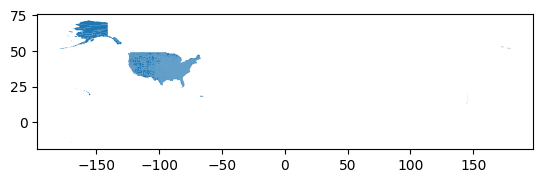

In [33]:
# Take a quick look
us.plot()

In [34]:
# To filter out NJ, we first need to see which column we can use
us.columns

Index(['STATEFP', 'COUNTYFP', 'COUNTYNS', 'GEOID', 'GEOIDFQ', 'NAME',
       'NAMELSAD', 'LSAD', 'CLASSFP', 'MTFCC', 'CSAFP', 'CBSAFP', 'METDIVFP',
       'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry'],
      dtype='str')

In [35]:
# We can use `STATEFP`
us.head()

,STATEFP,COUNTYFP,COUNTYNS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,40,075,01101825,40075,0500000US40075,Kiowa,Kiowa County,06,H1,G4020,NaN,NaN,NaN,A,2629039892,40296743,+34.9214893,-098.9816168,"POLYGON ((-98.95506 35.11643, -98.94903 35.116..."
1,46,079,01265776,46079,0500000US46079,Lake,Lake County,06,H1,G4020,NaN,NaN,NaN,A,1457916151,31746795,+44.0284497,-097.1232229,"POLYGON ((-96.88886 43.9353, -96.88886 43.9351..."
2,37,033,01008542,37033,0500000US37033,Caswell,Caswell County,06,H1,G4020,NaN,NaN,NaN,A,1102042927,8293623,+36.3943252,-079.3396193,"POLYGON ((-79.14343 36.4422, -79.14345 36.4418..."
3,48,377,01383974,48377,0500000US48377,Presidio,Presidio County,06,H1,G4020,NaN,NaN,NaN,A,9985057447,1773188,+30.0058912,-104.2616192,"POLYGON ((-104.98078 30.62552, -104.98073 30.6..."
4,39,057,01074041,39057,0500000US39057,Greene,Greene County,06,H1,G4020,212,19430,NaN,A,1071302625,6798109,+39.6874785,-083.8948943,"POLYGON ((-84.10668 39.68891, -84.10662 39.689..."


Read about ANSI and FIPS on the U.S. Census Bureau's website:

[American National Standards Institute (ANSI), Federal Information Processing Series (FIPS), and Other Standardized Geographic Codes](https://www.census.gov/library/reference/code-lists/ansi.html)

<Axes: >

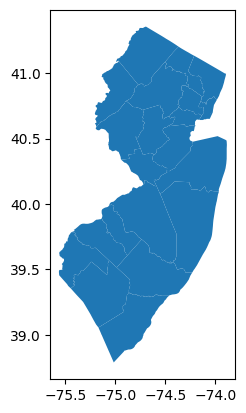

In [36]:
# Filter out NJ
nj = us[us.STATEFP=='34'].copy()
nj.plot()

In [37]:
# Let's say we want to look at the drought severity,
# electricity generation, and emissions across NJ

# As the electricity data we collected is for each plant,
# we can aggregate the total net generation at each county,
# and calculate the averaged emission in tons/MWh to represent the emission invensity

In [38]:
# We have already defined a list of counties in NJ
counties

<StringArray>
[  'Atlantic',     'Bergen', 'Burlington',     'Camden',   'Cape May',
 'Cumberland',      'Essex', 'Gloucester',     'Hudson',  'Hunterdon',
     'Mercer',  'Middlesex',   'Monmouth',     'Morris',      'Ocean',
    'Passaic',      'Salem',   'Somerset',     'Sussex',      'Union',
     'Warren']
Length: 21, dtype: str

In [39]:
# Now let's add up the total electricity generation, and calculate the averaged emission
generation = []
emissions = []
for county in counties:
    total_gen = (egrid_processed['Generation(MWh)'][egrid_processed.County==county]).sum()
    generation.append(total_gen)
    total_emissions = (egrid_processed['Emissions(tons)'][egrid_processed.County==county]).sum()
    if total_gen == 0:
        avg = 0
    else: avg = total_emissions/total_gen
    emissions.append(avg)

In [40]:
# Make a new dataframe with the aggregated data
egrid_agg = pd.DataFrame({
    'County': counties,
    'Generation(MWh)': generation,
    'Emissions(tons/MWh)': emissions,
})
egrid_agg

,County,Generation(MWh),Emissions(tons/MWh)
0,Atlantic,1.657770e+05,3.681404e-01
1,Bergen,2.639940e+06,4.675852e-01
2,Burlington,2.969330e+05,8.972316e-02
3,Camden,3.243280e+05,7.741944e-01
4,Cape May,4.290000e+03,2.331002e-07
5,Cumberland,3.497980e+05,4.688819e-01
6,Essex,4.238577e+06,4.770519e-01
7,Gloucester,2.887071e+06,4.527723e-01
8,Hudson,9.547490e+05,5.561256e-01
9,Hunterdon,1.299260e+05,1.807826e-01


In [41]:
# We notice that the generation for Warren county is negative (importing electricity),
# so we set the emissions to 0, instead of using a negative value
egrid_agg.iloc[-1, -1] = 0

In [42]:
# Now let's merge the drought and electricity data
merged_data = drought_avg.merge(egrid_agg, on='County')
merged_data.head()

,FIPS,County,State,Country,DSCI,Generation(MWh),Emissions(tons/MWh)
0,34001,Atlantic,New Jersey,USA,75.519464,165776.999,3.681404e-01
1,34003,Bergen,New Jersey,USA,55.934138,2639940.000,4.675852e-01
2,34005,Burlington,New Jersey,USA,55.092605,296933.000,8.972316e-02
3,34007,Camden,New Jersey,USA,58.714483,324328.001,7.741944e-01
4,34009,Cape May,New Jersey,USA,87.965785,4290.000,2.331002e-07


In [43]:
# Merge in the geo info
# We need to ensure there was one common column in the two dataframes to be merged
# In this case, we use `FIPS`
nj['FIPS'] = (nj.STATEFP + nj.COUNTYFP).astype('int64')
nj = nj.merge(merged_data, on='FIPS')
nj.head()

,STATEFP,COUNTYFP,COUNTYNS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,...,INTPTLAT,INTPTLON,geometry,FIPS,County,State,Country,DSCI,Generation(MWh),Emissions(tons/MWh)
0,34,029,00882279,34029,0500000US34029,Ocean,Ocean County,06,H1,G4020,...,+39.8656690,-074.2588636,"POLYGON ((-74.41689 39.82268, -74.41713 39.823...",34029,Ocean,New Jersey,USA,52.302452,659687.002,0.408246
1,34,025,00882910,34025,0500000US34025,Monmouth,Monmouth County,06,H1,G4020,...,+40.2870481,-074.1524456,"POLYGON ((-74.03864 40.10446, -74.03888 40.104...",34025,Monmouth,New Jersey,USA,46.282950,213563.000,0.000000
2,34,017,00882278,34017,0500000US34017,Hudson,Hudson County,06,H1,G4020,...,+40.7313751,-074.0786014,"POLYGON ((-74.02064 40.73039, -74.02097 40.729...",34017,Hudson,New Jersey,USA,54.703793,954749.002,0.556126
3,34,001,00882270,34001,0500000US34001,Atlantic,Atlantic County,06,H1,G4020,...,+39.4693555,-074.6337591,"POLYGON ((-74.5864 39.3099, -74.58665 39.30993...",34001,Atlantic,New Jersey,USA,75.519464,165776.999,0.368140
4,34,015,00882277,34015,0500000US34015,Gloucester,Gloucester County,06,H1,G4020,...,+39.7228754,-075.1456807,"POLYGON ((-75.11506 39.86153, -75.11508 39.861...",34015,Gloucester,New Jersey,USA,65.353333,2887070.910,0.452772


<Axes: >

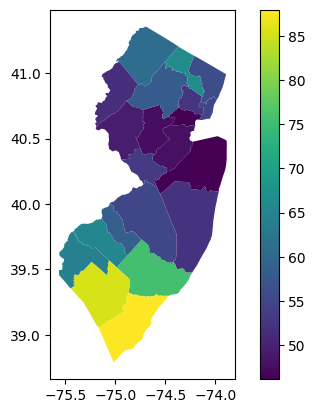

In [44]:
# Plot by drought severity
nj.plot(column='DSCI', legend=True)

<Axes: >

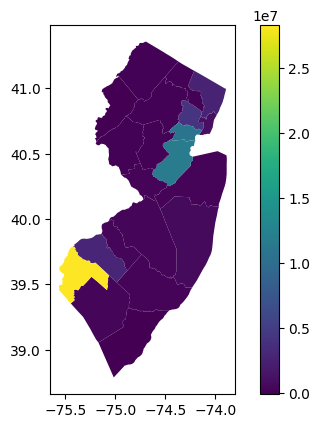

In [45]:
# Plot by net electricity generation
nj.plot(column='Generation(MWh)', legend=True)

<Axes: >

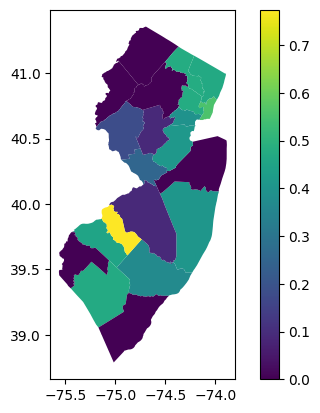

In [46]:
# Plot by emissions
nj.plot(column='Emissions(tons/MWh)', legend=True)

In [47]:
# Formatting in Python isn't that easy!
# So let's export the data and use ArcGIS to make it much nicer
# Note that we need to export as shapefile so that ArcGIS can import it correctly
nj.to_file('data/3_CompiledData.geojson', driver='GeoJSON')